In [102]:
import kairo
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("..") / ".env")

True

In [103]:
log = kairo.read_log("../data/drifted_logs/time_fast/sudden/bank_account_closure/bank_account_closure_time_fast_x05_sudden.xes",
    case_id = "case:concept:name",
    activity = "concept:name",
    timestamp = "time:timestamp",
    #event_id = "event:uidd",
    start_timestamp = "start:timestamp",
    resource = "org:resource",
    #event_duration = "event:runtime_min")
    )
log.head()

parsing log, completed traces :: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 32429/32429 [00:02<00:00, 10881.16it/s]


,concept:name,start_timestamp,time:timestamp,org:resource,org:role,lifecycle:transition,CLOSURE_TYPE,CLOSURE_REASON,case:concept:name
0,Request created,2017-05-29 08:47:46+00:00,2017-05-29 08:49:25+00:00,6,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
1,Evaluating Request (NO registered letter),2017-05-29 08:49:25+00:00,2017-05-29 08:52:49+00:00,7,DIRECTOR,complete,Client Recess,1 - Client lost,case_000000
2,Service closure Request with network responsib...,2017-05-29 08:56:04+00:00,2017-05-29 09:02:39+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
3,Service closure Request with BO responsibility,2017-05-29 09:02:39+00:00,2017-05-29 11:23:33+00:00,BOF,BACK-OFFICE,complete,Client Recess,1 - Client lost,case_000000
4,Network Adjustment Requested,2017-05-29 11:23:33+00:00,2017-05-31 09:26:08+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000


In [104]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 32429,
 'events': 212721,
 'activities': 15,
 'resources': 654,
 'start': Timestamp('2017-05-29 08:49:25+0000', tz='UTC'),
 'end': Timestamp('2019-03-06 16:38:59+0000', tz='UTC'),
 'span_minutes': 930709.5666666667,
 'tpt_days_min': 0.0,
 'tpt_days_mean': 13.45629664160194,
 'tpt_days_median': 6.074346064814815,
 'tpt_days_max': 503.5870949074074,
 'length_min': 2,
 'length_mean': 6.559591723457399,
 'length_median': 7.0,
 'length_max': 23,
 'activity_counts': concept:name
 Request created                                        32377
 Service closure Request with BO responsibility         30130
 Pending Request for Reservation Closure                29151
 Request completed with account closure                 29031
 Pending Liquidation Request                            29000
 Service closure Request with network responsibility    25009
 Authorization Requested                                12675
 Evaluating Request (NO registered letter)              11080
 Back-Office Adj

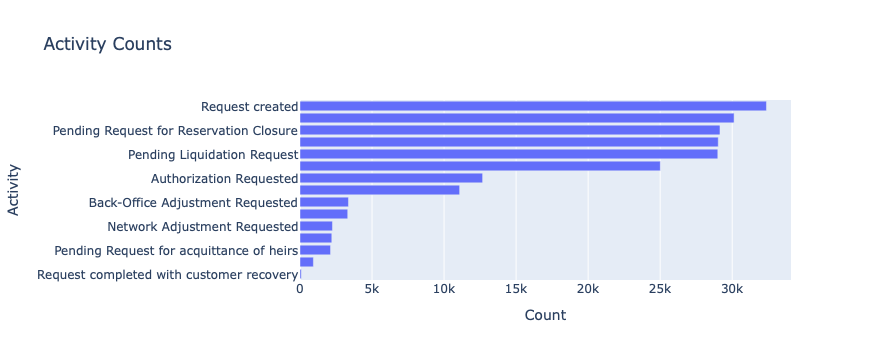

In [105]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [106]:
features = kairo.compute_features_intra(log, sliding_window_size=1)
features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [107]:
std_features = kairo.standardize(features, method="minmax")
std_features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


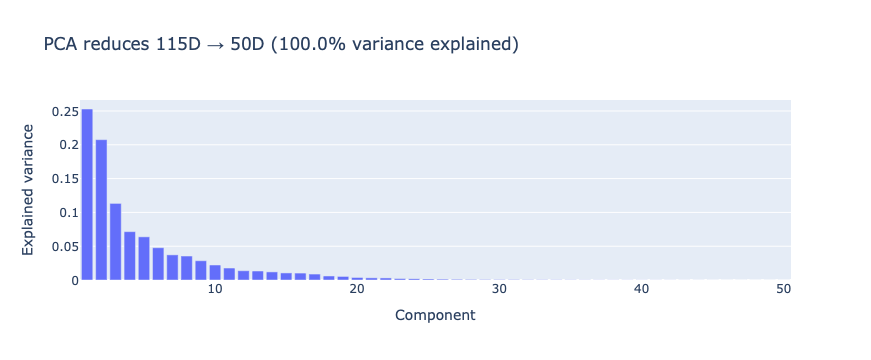

In [108]:
pca = kairo.compute_pca(std_features, num_components=50)
pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()
#pca

In [14]:
compressed_features = kairo.apply_pca(std_features, pca, cut_component=15)
compressed_features

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13,pc_14,pc_15
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530,0.327245,-0.501438,-0.215653,-0.267268,-0.115837,-0.059156,0.025088,-0.085787,-0.040240,0.003012
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966,-0.509641,-0.131702,1.075069,0.750329,-0.464401,0.361062,-0.132697,-0.290555,-0.059899,0.000419
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052,-0.749163,-0.222386,-0.145608,-0.694494,0.391446,0.597275,-0.118122,0.308936,0.224335,-0.046807
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020,1.041550,0.080662,0.028620,0.184669,0.144771,-0.177328,0.085109,-0.113696,0.087432,-0.069061
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276,0.088747,-0.141289,0.058532,-0.137768,-0.144888,0.056314,0.737973,-0.191332,0.312050,1.088191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,-0.220422,-0.038467
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,-0.059358,0.000534
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,-0.220422,-0.038467
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,-0.059358,0.000534


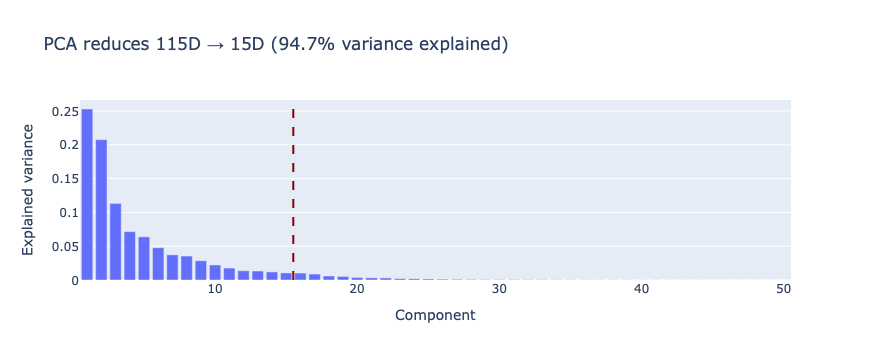

In [15]:
pca_plot_cut = kairo.plot_pca_variances(pca, cut_component=15)
pca_plot_cut.show()

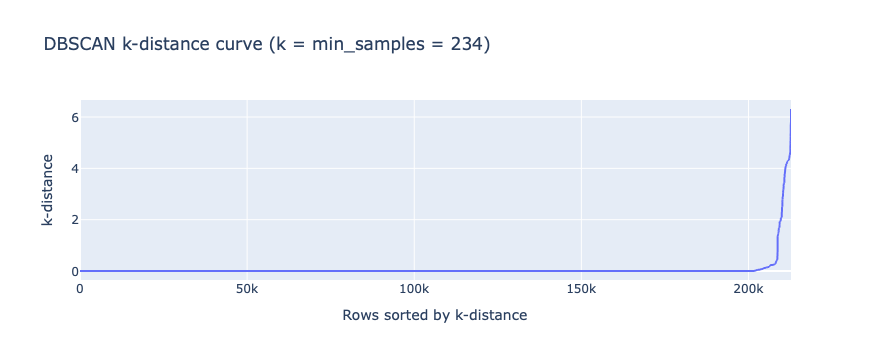

In [121]:
# heuristic: min_samples * num_dimensions (not working good here)
# try around min_samples >= D + 1 where D is the number of PCA dimensions
k_distances_plot = kairo.plot_dbscan_k_distance(compressed_features, min_samples=234, distance="manhattan")
k_distances_plot.show()

In [122]:
dbscan = kairo.compute_dbscan(compressed_features, min_samples=234, eps=0.7, distance="manhattan")
clusters = kairo.get_dbscan_clusters(compressed_features, dbscan)
clusters

,cluster
0,0
1,1
2,5
3,11
4,14
...,...
212716,4
212717,0
212718,4
212719,0


In [ ]:
clustering_scores = [
    {"type": "DBCV", "value": kairo.compute_dbcv(compressed_features, clusters, distance=dbscan.metric)},
    {"type": "Silhouette", "value": kairo.compute_silhouette(compressed_features, clusters, distance=dbscan.metric)},
    {"type": "Calinski-Harabasz", "value": kairo.compute_calinski_harabasz(compressed_features, clusters)},
]
clustering_scores

In [123]:
features_and_clusters = pd.concat([compressed_features, clusters], axis=1)
features_and_clusters

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13,pc_14,pc_15,cluster
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530,0.327245,-0.501438,-0.215653,-0.267268,-0.115837,-0.059156,0.025088,-0.085787,-0.040240,0.003012,0
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966,-0.509641,-0.131702,1.075069,0.750329,-0.464401,0.361062,-0.132697,-0.290555,-0.059899,0.000419,1
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052,-0.749163,-0.222386,-0.145608,-0.694494,0.391446,0.597275,-0.118122,0.308936,0.224335,-0.046807,5
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020,1.041550,0.080662,0.028620,0.184669,0.144771,-0.177328,0.085109,-0.113696,0.087432,-0.069061,11
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276,0.088747,-0.141289,0.058532,-0.137768,-0.144888,0.056314,0.737973,-0.191332,0.312050,1.088191,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,-0.220422,-0.038467,4
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,-0.059358,0.000534,0
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,-0.220422,-0.038467,4
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,-0.059358,0.000534,0


In [124]:
state_distances = kairo.get_dbscan_state_distances(dbscan)
state_distances

,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
0,0.000000,7.090367,4.580232,4.574765,7.504515,8.617445,6.815139,6.699742,6.684676,6.548508,...,8.844035,7.714207,9.488154,9.175882,9.731486,9.886973,10.011162,10.275958,7.363875,8.581851
1,7.090367,0.000000,6.249305,6.031667,8.157798,7.341445,7.951177,7.581407,8.034563,9.159385,...,9.533251,9.725437,10.378045,11.008668,10.359882,11.085632,11.654932,11.682167,10.367791,11.435235
2,4.580232,6.249305,0.000000,3.833209,6.304771,9.240046,4.450410,7.059409,6.557311,4.752549,...,8.789381,8.816256,10.271711,10.163777,10.343835,9.674970,10.753633,10.899696,8.657079,9.525981
3,4.574765,6.031667,3.833209,0.000000,4.064945,8.823538,6.887946,6.397145,5.909683,7.366609,...,7.141676,8.553761,9.688994,9.957498,10.013853,8.356869,10.397280,10.802178,8.349894,9.530645
4,7.504515,8.157798,6.304771,4.064945,0.000000,11.549680,9.051149,8.011723,7.492082,9.533321,...,10.770650,11.248540,10.880436,12.188228,11.107729,11.693319,11.550377,11.854798,11.028679,11.903773
5,8.617445,7.341445,9.240046,8.823538,11.549680,0.000000,7.749957,6.707635,10.419466,9.514451,...,11.390289,10.643988,11.676681,11.756827,11.783337,12.532132,12.274108,12.394048,11.003549,11.990479
6,6.815139,7.951177,4.450410,6.887946,9.051149,7.749957,0.000000,6.375729,8.372232,5.060189,...,10.099835,9.743668,10.816492,11.064952,10.726068,11.969477,12.143642,12.104350,10.362971,11.341736
7,6.699742,7.581407,7.059409,6.397145,8.011723,6.707635,6.375729,0.000000,7.257307,8.374559,...,9.207119,8.622998,9.636869,10.031419,9.991135,10.421420,10.429370,10.747898,9.372530,10.501993
8,6.684676,8.034563,6.557311,5.909683,7.492082,10.419466,8.372232,7.257307,0.000000,5.324588,...,10.227449,10.198157,11.065432,11.358005,10.669796,11.661331,12.166761,11.737117,10.599701,11.617968
9,6.548508,9.159385,4.752549,7.366609,9.533321,9.514451,5.060189,8.374559,5.324588,0.000000,...,10.902439,9.480981,10.867457,10.409374,10.650140,12.218915,11.790622,11.579613,9.828381,10.635923


In [125]:
state_freqs = kairo.get_dbscan_state_frequencies(features_and_clusters)
state_freqs

state
noise     4015
0        32377
1        11074
2         2074
3          912
4         3235
5        10993
6         1353
7        12638
8         2379
9          710
10         828
11       10955
12        1350
13         316
14         319
15        2376
16         660
17       12457
18       10686
19        1304
20         253
21         736
22         825
23       12257
24         728
25        1539
26        1542
27         652
28        1298
29        2360
30        1298
31       10951
32         388
33       10661
34        1303
35         254
36        1459
37         614
38        1066
39         388
40       10273
41         246
42        1264
43         613
44       10898
45        1411
46        1444
47         678
48         606
49        1411
50         678
51        8876
52         740
Name: events, dtype: int64

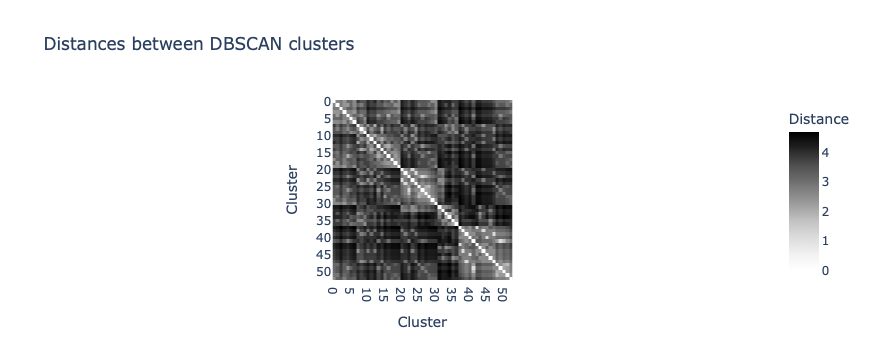

In [117]:
distances_plot = kairo.plot_dbscan_distances(state_distances)
distances_plot.show()

In [118]:
color_mapping = kairo.compute_dbscan_color_mapping(dbscan)

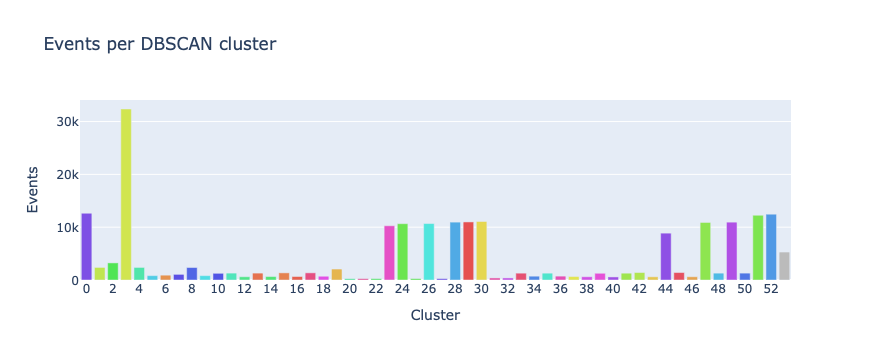

In [119]:
freqs_plot = kairo.plot_dbscan_frequencies(state_freqs, color_mapping)
freqs_plot.show()

In [21]:
case_trajectory = kairo.get_dbscan_case_trajectory(features_and_clusters, case_id="case_000001")
case_trajectory

,state,start,end,duration,events
0,0,2017-06-05 13:34:59+00:00,2017-06-05 14:20:48+00:00,0 days 00:45:49,1
1,1,2017-06-05 14:20:48+00:00,2017-06-12 08:28:02+00:00,6 days 18:07:14,1
2,2,2017-06-12 08:28:02+00:00,2017-06-14 10:11:14+00:00,2 days 01:43:12,1
3,3,2017-06-14 10:11:14+00:00,2018-02-09 13:13:06+00:00,240 days 03:01:52,1
4,noise,2018-02-09 13:13:06+00:00,2018-09-13 08:57:36+00:00,215 days 19:44:30,8


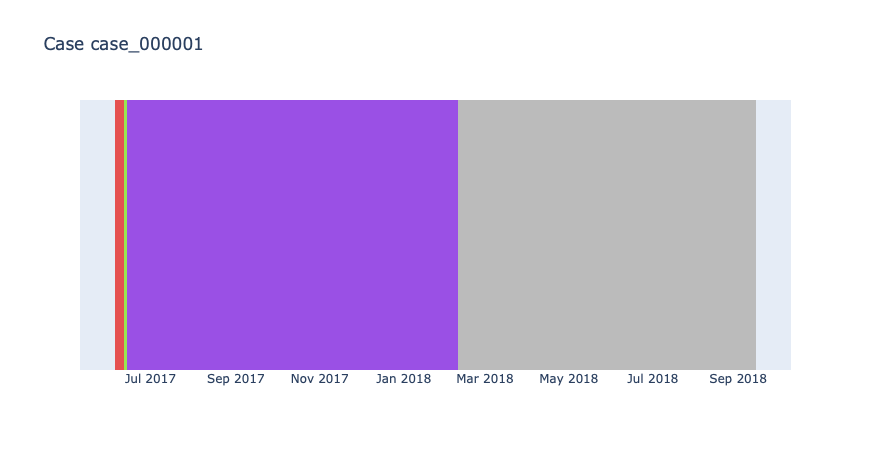

In [22]:
case_trajectory_plot = kairo.plot_dbscan_case_trajectory(case_trajectory, color_mapping, case_id="case_000001")
case_trajectory_plot

In [23]:
case_trajectories = kairo.get_dbscan_trajectories(features_and_clusters, max_cases=10)
case_trajectories

,case,state,start,end,duration,events
0,case_000000,0,2017-05-29 08:49:25+00:00,2017-05-29 08:52:49+00:00,0 days 00:03:24,1
1,case_000000,noise,2017-05-29 08:52:49+00:00,2017-06-15 03:04:22+00:00,16 days 18:11:33,8
2,case_000001,0,2017-06-05 13:34:59+00:00,2017-06-05 14:20:48+00:00,0 days 00:45:49,1
3,case_000001,1,2017-06-05 14:20:48+00:00,2017-06-12 08:28:02+00:00,6 days 18:07:14,1
4,case_000001,2,2017-06-12 08:28:02+00:00,2017-06-14 10:11:14+00:00,2 days 01:43:12,1
5,case_000001,3,2017-06-14 10:11:14+00:00,2018-02-09 13:13:06+00:00,240 days 03:01:52,1
6,case_000001,noise,2018-02-09 13:13:06+00:00,2018-09-13 08:57:36+00:00,215 days 19:44:30,8
7,case_000004,0,2017-07-12 10:34:30+00:00,2017-07-12 10:37:17+00:00,0 days 00:02:47,1
8,case_000004,noise,2017-07-12 10:37:17+00:00,2018-09-18 03:03:16+00:00,432 days 16:25:59,6
9,case_000005,0,2017-07-13 09:05:45+00:00,2018-02-09 11:24:06+00:00,211 days 02:18:21,1


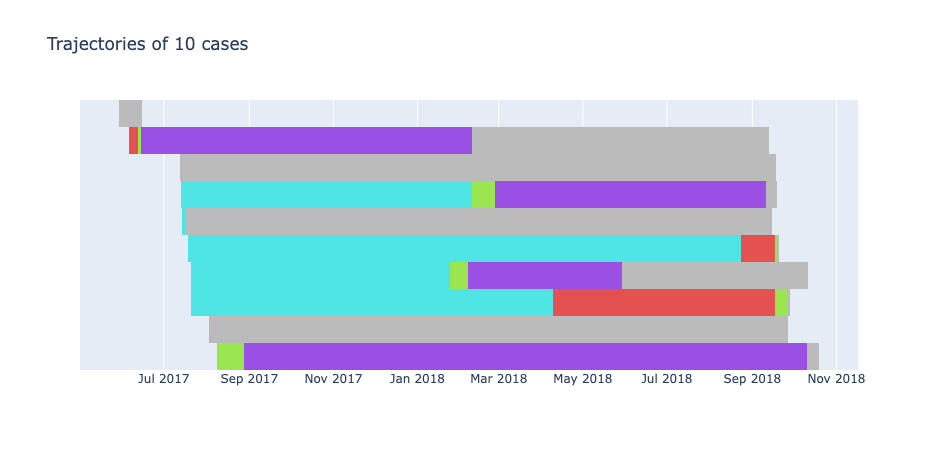

In [24]:
case_trajectories_plot = kairo.plot_dbscan_trajectories(case_trajectories, color_mapping)
case_trajectories_plot

In [25]:
freq_distributions = kairo.compute_state_distributions(features_and_clusters, window="30D")
freq_distributions

state,noise,0,1,2,3
window,,,,,
2017-05-24 00:00:00+00:00,0.615385,0.153846,0.076923,0.076923,0.076923
2017-06-23 00:00:00+00:00,0.250000,0.750000,0.000000,0.000000,0.000000
2017-07-23 00:00:00+00:00,0.200000,0.400000,0.200000,0.200000,0.000000
2017-08-22 00:00:00+00:00,0.055556,0.611111,0.111111,0.111111,0.111111
2017-09-21 00:00:00+00:00,0.161290,0.516129,0.161290,0.064516,0.096774
2017-10-21 00:00:00+00:00,0.400000,0.400000,0.142857,0.028571,0.028571
2017-11-20 00:00:00+00:00,0.279070,0.348837,0.139535,0.116279,0.116279
2017-12-20 00:00:00+00:00,0.140351,0.403509,0.245614,0.140351,0.070175
2018-01-19 00:00:00+00:00,0.216867,0.397590,0.192771,0.108434,0.084337


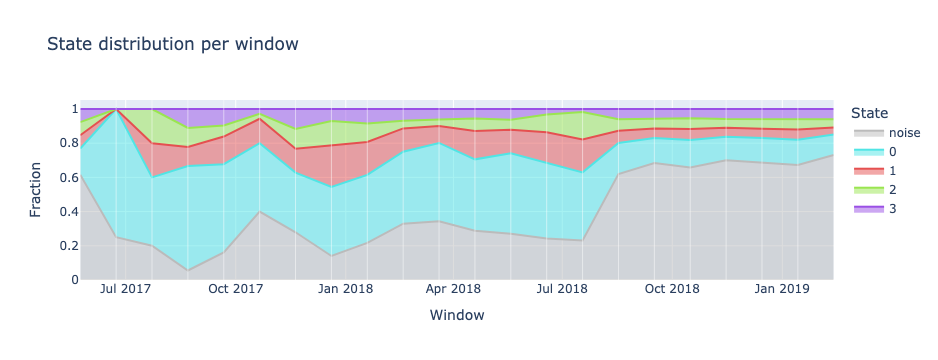

In [26]:
distributions_plot = kairo.plot_state_distributions(freq_distributions, color_mapping)
distributions_plot.show()

In [27]:
divergences = kairo.compute_divergences(freq_distributions)
divergences

,window,score
0,2017-05-24 00:00:00+00:00,NaN
1,2017-06-23 00:00:00+00:00,0.962893
2,2017-07-23 00:00:00+00:00,7.349459
3,2017-08-22 00:00:00+00:00,2.115664
4,2017-09-21 00:00:00+00:00,0.096389
5,2017-10-21 00:00:00+00:00,0.185881
6,2017-11-20 00:00:00+00:00,0.174925
7,2017-12-20 00:00:00+00:00,0.092133
8,2018-01-19 00:00:00+00:00,0.029320
9,2018-02-18 00:00:00+00:00,0.060176


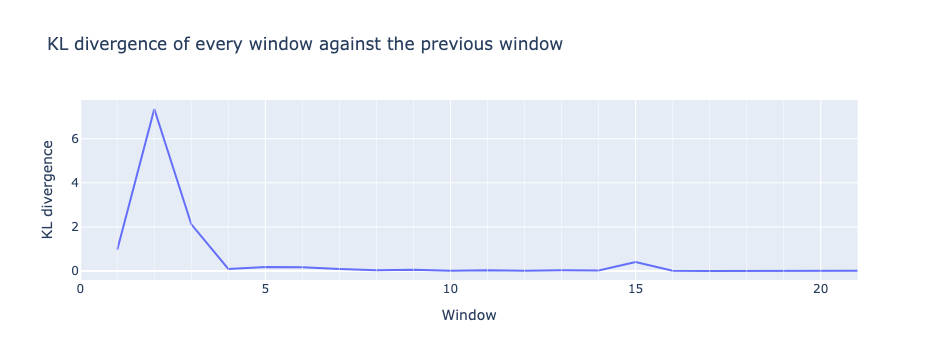

In [28]:
divergences_plot = kairo.plot_divergences(divergences)
divergences_plot.show()

In [29]:
abs_log_stats = kairo.abstract_log_stats(stats)
abs_log_stats

'Event log: 212,721 events of 32,429 cases, 15 activities and 654 resources, from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nThroughput time per case in days: min 0.00, mean 13.46, median 6.07, max 503.59.\nEvents per case: min 2, mean 6.6, median 7.0, max 23.\nEvents per activity: Request created (32,377), Service closure Request with BO responsibility (30,130), Pending Request for Reservation Closure (29,151), Request completed with account closure (29,031), Pending Liquidation Request (29,000), Service closure Request with network responsibility (25,009), Authorization Requested (12,675), Evaluating Request (NO registered letter) (11,080), Back-Office Adjustment Requested (3,363), Request deleted (3,312), Network Adjustment Requested (2,252), Evaluating Request (WITH registered letter) (2,207), Pending Request for acquittance of heirs (2,119), Pending Request for Network Information (929), Request completed with customer recovery (86)\nMost active resources: BOF (113,9

In [30]:
abs_features = kairo.abstract_features(features)
abs_features

'Intra-case feature matrix: 212,721 rows, one per event, each describing its case up to and including that event, with 115 feature columns.\nThe events belong to 32,429 cases.\nThey happened from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nFeature groups:\n- act_freqs (share of every activity among the events of the case so far): 15 columns, mean value 0.067, non-zero in 26.4% of the cells, highest column means act_freqs:Request created = 0.378, act_freqs:Service closure Request with network responsibility = 0.162, act_freqs:Service closure Request with BO responsibility = 0.118\n- df_counts (how often every directly-follows pair happened in the case so far): 54 columns, mean value 0.056, non-zero in 5.6% of the cells, highest column means df_counts:Service closure Request with BO responsibility -> Pending Request for Reservation Closure = 0.419, df_counts:Request created -> Service closure Request with network responsibility = 0.387, df_counts:Service closure Request with

In [31]:
abs_pca = kairo.abstract_pca(pca, cut_component=13)
abs_pca

'PCA fitted 50 components on 115 feature columns. The cut keeps the first 13, which explain 92.5% of the variance.\nExplained variance per component: pc_1 25.3%, pc_2 20.8%, pc_3 11.3%, pc_4 7.2%, pc_5 6.4%, pc_6 4.8%, pc_7 3.7%, pc_8 3.5%, pc_9 2.8%, pc_10 2.2%, pc_11 1.8%, pc_12 1.4%, pc_13 1.3%, pc_14 1.2%, pc_15 1.0%, pc_16 1.0%, pc_17 0.9%, pc_18 0.6%, pc_19 0.5%, pc_20 0.4%, pc_21 0.3%, pc_22 0.3%, pc_23 0.2%, pc_24 0.2%, pc_25 0.1%, pc_26 0.1%, pc_27 0.1%, pc_28 0.1%, pc_29 0.1%, pc_30 0.1%, pc_31 0.0%, pc_32 0.0%, pc_33 0.0%, pc_34 0.0%, pc_35 0.0%, pc_36 0.0%, pc_37 0.0%, pc_38 0.0%, pc_39 0.0%, pc_40 0.0%, pc_41 0.0%, pc_42 0.0%, pc_43 0.0%, pc_44 0.0%, pc_45 0.0%, pc_46 0.0%, pc_47 0.0%, pc_48 0.0%, pc_49 0.0%, pc_50 0.0%\nFeatures with the strongest loadings on every kept component:\n- pc_1: act_set:Pending Request for Reservation Closure (+0.34), act_set:Service closure Request with BO responsibility (+0.34), act_set:Pending Liquidation Request (+0.30), df_counts:Pending R

In [32]:
abs_states = kairo.abstract_states(state_freqs, state_distances, color_mapping, clustering_scores=clustering_scores)
abs_states

'5 states occur among the 212,721 events. Events per state:\n- noise: 142,992 events (67.2%)\n- 0: 32,377 events (15.2%)\n- 1: 12,638 events (5.9%)\n- 2: 12,457 events (5.9%)\n- 3: 12,257 events (5.8%)\nNearest and farthest other state for every state, by the distance between them:\n- 0: nearest 1 (6.68), farthest 3 (8.27)\n- 1: nearest 0 (6.68), farthest 3 (8.21)\n- 2: nearest 3 (5.95), farthest 0 (8.04)\n- 3: nearest 2 (5.95), farthest 0 (8.27)\nColors of the states in the plots:\n- 0: #50e5e5 (cyan)\n- 1: #e55050 (red)\n- 2: #9ae550 (green)\n- 3: #9a50e5 (purple)\n- noise: #bbbbbb (grey)'

In [33]:
abs_case_trajectory = kairo.abstract_case_trajectory(case_trajectory, "case_000001")
abs_case_trajectory

'Trajectory of case case_000001, one line per visit of a state, in order:\n- 0 from 2017-06-05 13:34:59+00:00 to 2017-06-05 14:20:48+00:00 (0 days 00:45:49, 1 events)\n- 1 from 2017-06-05 14:20:48+00:00 to 2017-06-12 08:28:02+00:00 (6 days 18:07:14, 1 events)\n- 2 from 2017-06-12 08:28:02+00:00 to 2017-06-14 10:11:14+00:00 (2 days 01:43:12, 1 events)\n- 3 from 2017-06-14 10:11:14+00:00 to 2018-02-09 13:13:06+00:00 (240 days 03:01:52, 1 events)\n- noise from 2018-02-09 13:13:06+00:00 to 2018-09-13 08:57:36+00:00 (215 days 19:44:30, 8 events)'

In [34]:
abs_case_trajectories = kairo.abstract_case_trajectories(case_trajectories)
abs_case_trajectories

'Trajectories of 10 cases, from 2017-05-29 08:49:25+00:00 to 2018-10-19 09:50:35+00:00. A case visits 3.8 states on average and lasts 432 days 17:13:14 (median).\nThe most common paths through the states, with how many cases took them:\n- 0 -> 1 -> 2 -> 3 -> noise: 6 cases (60.0%)\n- 0 -> noise: 4 cases (40.0%)\nThe most common moves from one state to the next:\n- 0 -> 1: 6 times\n- 1 -> 2: 6 times\n- 2 -> 3: 6 times\n- 3 -> noise: 6 times\n- 0 -> noise: 4 times\nStates the cases start in: 0 (10)\nStates the cases end in: noise (10)'

In [35]:
abs_distributions = kairo.abstract_distributions(freq_distributions)
abs_distributions

'State distribution over 22 calendar windows from 2017-05-24 00:00:00+00:00 to 2019-02-13 00:00:00+00:00: the share of every state among the events of each window.\nShare of every state over the windows, mean, lowest and highest:\n- noise: mean 39.9%, lowest 5.6% in the window starting 2017-08-22 00:00:00+00:00, highest 73.1% in the window starting 2019-02-13 00:00:00+00:00\n- 0: mean 34.7%, lowest 12.0% in the window starting 2019-02-13 00:00:00+00:00, highest 75.0% in the window starting 2017-06-23 00:00:00+00:00\n- 1: mean 11.7%, lowest 0.0% in the window starting 2017-06-23 00:00:00+00:00, highest 24.6% in the window starting 2017-12-20 00:00:00+00:00\n- 2: mean 7.9%, lowest 0.0% in the window starting 2017-06-23 00:00:00+00:00, highest 20.0% in the window starting 2017-07-23 00:00:00+00:00\n- 3: mean 5.9%, lowest 0.0% in the window starting 2017-06-23 00:00:00+00:00, highest 11.6% in the window starting 2017-11-20 00:00:00+00:00\nThe largest changes from one window to the next, wi

In [36]:
abs_divergences = kairo.abstract_divergences(divergences, divergence="kl", reference="recent")
abs_divergences

'Drift signal: the KL divergence between the state distribution of every calendar window and the mean of the 5 windows before it, over 22 windows from 2017-05-24 00:00:00+00:00 to 2019-02-13 00:00:00+00:00. The windows are numbered from 0 as in the plot.\nScores: median 0.032, mean 0.553, highest 7.349.\nThe windows with the highest scores:\n- window 2, starting 2017-07-23 00:00:00+00:00: 7.349\n- window 3, starting 2017-08-22 00:00:00+00:00: 2.116\n- window 1, starting 2017-06-23 00:00:00+00:00: 0.963\n- window 15, starting 2018-08-17 00:00:00+00:00: 0.413\n- window 5, starting 2017-10-21 00:00:00+00:00: 0.186'

In [ ]:
llm = kairo.LLMConnector(
    provider="custom",
    #api_key=os.environ["ANTHROPIC_API_KEY"],
    model="Qwen/Qwen3-VL-32B-Instruct",
    base_url="http://137.226.117.70:8000/v1"
)

In [ ]:
chat_history = []
total_out_tokens = 0

In [ ]:
# For initial request
messages = kairo.create_messages(provider="custom",
                                system_prompt=kairo.DEFAULT_SYSTEM_PROMPT, 
                                prompts=[abs_log_stats + abs_features + 
                                    abs_pca + abs_states + abs_case_trajectory + abs_case_trajectories
                                    + abs_distributions + abs_divergences + 
                                    "Analyze and summarize the given information. Do not use markdown format, just raw text"],
                                plots=[activity_plot, pca_plot_cut, distances_plot, freqs_plot,
                                            case_trajectory_plot, case_trajectories_plot,
                                            distributions_plot, divergences_plot])
chat_history += messages

num_tokens = kairo.count_input_tokens(provider="custom", messages=chat_history)
num_tokens

In [ ]:
# For follow up request
messages = kairo.create_messages(provider="custom",
                                system_prompt=None,
                                prompts=["what was my previous question very briefly"],
                                plots=[])
chat_history += messages

num_tokens = kairo.count_input_tokens(provider="custom", messages=chat_history)
num_tokens

In [ ]:
response = llm.call(messages=chat_history, max_tokens=64000)

answer = kairo.get_response_text(response)

chat_history.append({"role": "assistant", 
                     "content": answer})

print(answer)

In [ ]:
out_tokens = kairo.count_output_tokens("custom", response)
total_out_tokens += out_tokens
total_out_tokens

In [ ]:
print(kairo.get_chat_history(chat_history))